# Using nVenn2 with python

## Direct input

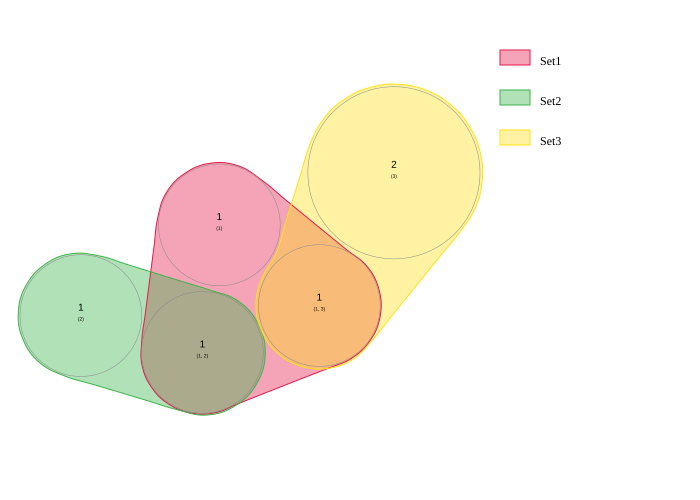

In [7]:
import nvenn2

from IPython.display import SVG, display
print("nVenn2 version: ")
!pip freeze | grep nvenn2
n = nvenn2.diagram("Set1 Set2 Set3\na a b\nb q d\nc  e", 0)
n.simulate()
display(SVG(n.to_svg()))

## Exploring diagram regions

In [8]:
print(n.get_venn_region(["Set1", "Set3"]))

['b']


## A more complex example from a text file
Input data are stored in four columns at [example.txt](../data/example.txt).

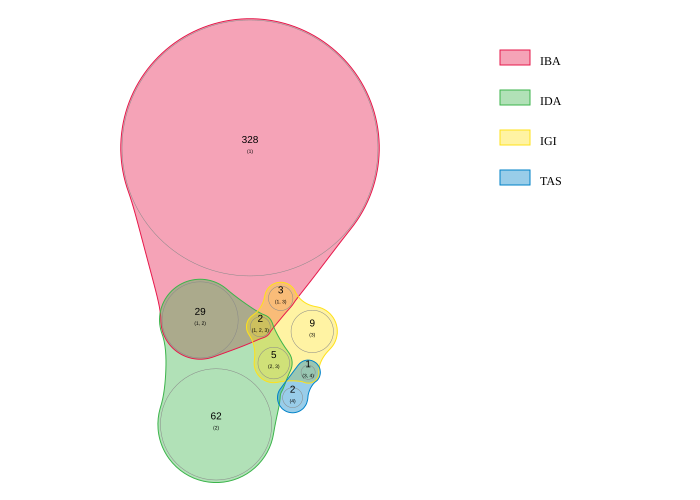

In [9]:
f = open("../data/example.txt")
x = nvenn2.diagram(f.read())
f.close()
x.simulate()
display(SVG(x.to_svg()))

Running the simulation repeatedly gives different diagrams, all of which should be equivalent. In very complex situations, some diagrams can be more simple than others. It is important to save the most interesting examples, as they will be lost if `simulate()` is run again.

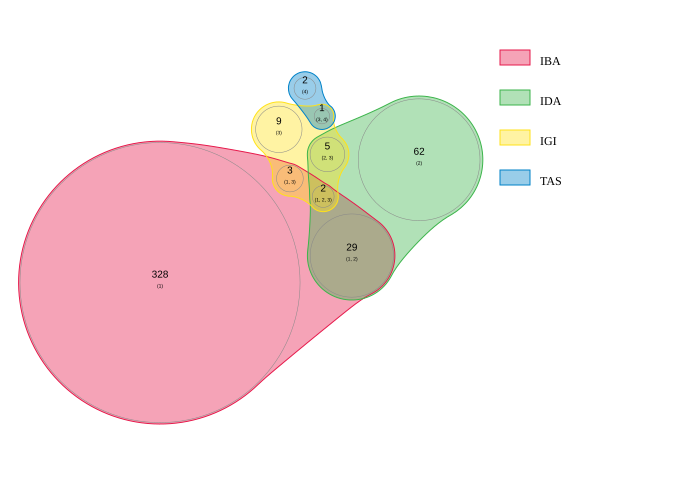

In [10]:
x.simulate()
display(SVG(x.to_svg()))

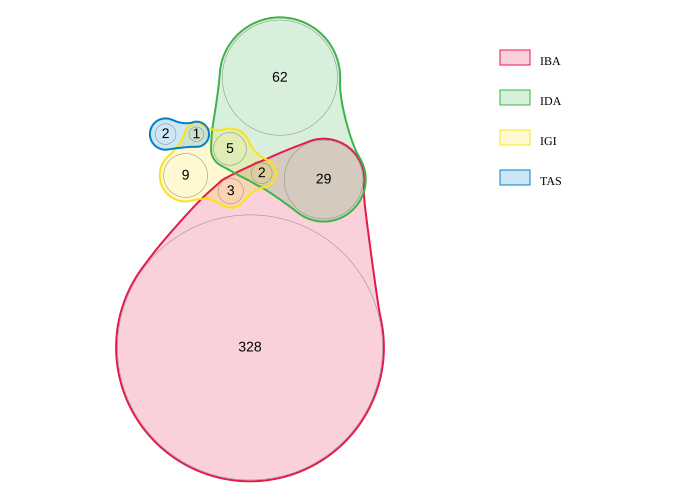

In [11]:
x.rotate_diagram(45)
x.set_opacity(0.2)
x.set_line_width(2)
x.set_font_size(14)
x.show_region_identifier(False)
display(SVG(x.to_svg()))

The diagrams can be saved as an SVG or HTML file. From the HTML file one can also download an SVG or PNG file.

In [12]:
f = open("../results/example.html", "w")
f.write(x.to_html())
f.close()

Now the file can be reached at [../results/example.html](../results/example.html). If you want to use the javascript functions, you need to trust the html code by pushing the corresponding button. Downloads will not probably work unless you download the web page.

# Exhaustive mode
You can also try every combination of swaps in the minimization steps. This is not advised, as getting this mode to give good results usually necessitates very large computing resources. To use this mode, you can pass a `maxlevel` value higher than zero to `simulate()`. A value of 1 checks all pairwise swaps, a value of 2 checks all double pairwise swaps, and so forth. If this mode is to be tried, we encourage the use of `estimate_exhaustive_run_time()` to ensure that the run is feasible in a reasonable time.

Estimated time: 0.7292386889457703


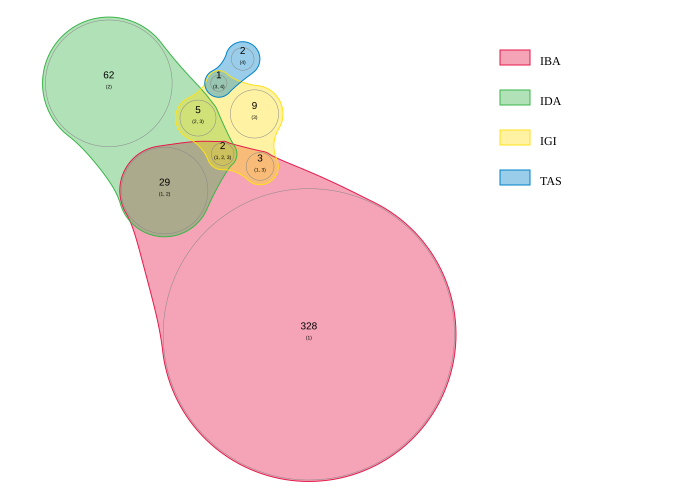

In [ ]:
g = open("../data/example.txt")
y = nvenn2.diagram(g.read())
g.close()
est = y.estimate_exhaustive_run_time(2)
print(f"Estimated time: {est} seconds")
if est < 5:
    y.simulate(2)
    display(SVG(y.to_svg()))

A `maxlevel` higher than or equal to the number of regions explores every combination, but the time needed for these steps grows exponentially with the number of regions and with `maxlevel`, so in many cases this will not be feasible.

In [18]:
est = y.estimate_exhaustive_run_time(9)
print(f"Estimated time: {est} seconds")

Estimated time: 2.3032028675079346 seconds
